# 1. Importing the libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.io as pio 
pio.renderers.default = "svg" 
import warnings
warnings.filterwarnings("ignore")

In [2]:
# !pip install plotly

# 2. Importing the dataset

In [3]:
raw_df = pd.read_csv('Zomato Chennai Listing 2020.csv',delimiter=",")

In [4]:
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# 3. Getting Basic Information about the Database

In [5]:
raw_df.replace(to_replace = ['None','Invalid','Does not offer Delivery','Does not offer Dining','Not enough Delivery Reviews',
                             'Not enough Dining Reviews'], value =np.nan,inplace=True)
raw_df.isnull().sum()

Zomato URL                  0
Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes               9641
Price for 2                 0
Dining Rating            5351
Dining Rating Count      5351
Delivery Rating          5851
Delivery Rating Count    5851
Features                    0
dtype: int64

In [6]:
raw_df.shape

(12032, 12)

In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             2391 non-null   object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    6681 non-null   object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  6181 non-null   object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [8]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


# 4. Cleaning the Dataset

# a. Dropping the column which are not required for futher analysis

In [9]:
raw_df.drop(['Zomato URL'], axis = 1, inplace=True)

In [10]:
raw_df.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# b. Removing the Null Records

In [11]:
# Checking for Null records
raw_df.isnull().sum()

Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes               9641
Price for 2                 0
Dining Rating            5351
Dining Rating Count      5351
Delivery Rating          5851
Delivery Rating Count    5851
Features                    0
dtype: int64

In [12]:
 # Checking for a null row 
 
# raw_df[raw_df['Top Dishes'].isnull()] 

In [13]:
# Replacing the other null records with NA 
raw_df.fillna('NA', inplace=True)

In [14]:
# Confirming all the null records are correct 
raw_df.isnull().sum()

Name of Restaurant       0
Address                  0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

# c. Converting the DataTypes of numerical columns to numeric dataype

In [15]:
raw_df

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],NA,350.0,NA,NA,NA,NA,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],NA,350.0,NA,NA,NA,NA,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],NA,350.0,NA,NA,NA,NA,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],NA,350.0,NA,NA,NA,NA,"['Breakfast', 'Delivery Only']"


In [16]:
# Checking for text values in the column before converting it to numeric datatype
raw_df['Dining Rating'].value_counts()

Dining Rating
NA     5351
3.6     584
3.5     553
3.7     525
3.4     500
3.3     463
3.8     460
3.2     433
3.9     379
3.1     363
2.0     354
3.0     302
4.0     288
2.9     257
4.1     221
2.8     192
4.2     142
2.7     138
4.3     105
2.6      99
2.5      71
4.4      61
2.4      46
4.5      36
2.3      32
2.2      20
4.6      17
4.7      12
2.1      10
4.9       7
4.8       4
1.9       3
1.7       2
0.3       1
1.0       1
Name: count, dtype: int64

In [17]:
# Replacing the text values with '0'
raw_df['Dining Rating'].replace(to_replace=['NA'], value='0', inplace=True)

In [18]:
# Checking for text values in the column before converting it to numeric datatype
raw_df['Dining Rating Count'].value_counts()

Dining Rating Count
NA      5351
4        339
5        271
6        248
8        180
        ... 
5821       1
742        1
1363       1
1094       1
1266       1
Name: count, Length: 792, dtype: int64

In [19]:
# Replacing the text values with '0'
raw_df['Dining Rating Count'].replace(to_replace=['NA'], value='0', inplace=True)

In [20]:
# Checking for text values in the column before converting it to numeric datatype
raw_df['Delivery Rating'].value_counts()

Delivery Rating
NA     5851
3.9    1383
3.8     701
4.0     570
3.7     559
4.1     468
3.6     465
4.2     401
3.5     314
4.3     277
3.4     259
3.3     189
4.4     128
3.2      93
3.1      79
3.0      63
4.5      55
2.9      39
2.8      26
4.6      24
2.7      19
2.6      17
2.5       9
0.3       8
2.4       7
1.8       5
2.3       5
2.0       5
2.2       5
4.7       4
2.1       2
1.6       1
1.5       1
Name: count, dtype: int64

In [21]:
# Replacing the text values with '0'
raw_df['Delivery Rating'].replace(to_replace=['NA'], value='0', inplace=True)

In [22]:
# Checking for text values in the column before converting it to numeric datatype
raw_df['Delivery Rating Count'].value_counts()

Delivery Rating Count
NA       5851
27         34
32         30
37         30
40         30
         ... 
50100       1
2744        1
10500       1
39200       1
1617        1
Name: count, Length: 2280, dtype: int64

In [23]:
# Replacing the text values with '0'
raw_df['Delivery Rating Count'].replace(to_replace=['NA'], value='0', inplace=True)

In [24]:
# Changing Data Type of the numerical columns
raw_df['Dining Rating'] = raw_df['Dining Rating'].astype('float64')
raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].astype('int64')
raw_df['Delivery Rating'] = raw_df['Delivery Rating'].astype('float64')
raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].astype('int64')


In [25]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Address                12032 non-null  object 
 2   Location               12032 non-null  object 
 3   Cuisine                12032 non-null  object 
 4   Top Dishes             12032 non-null  object 
 5   Price for 2            12032 non-null  float64
 6   Dining Rating          12032 non-null  float64
 7   Dining Rating Count    12032 non-null  int64  
 8   Delivery Rating        12032 non-null  float64
 9   Delivery Rating Count  12032 non-null  int64  
 10  Features               12032 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 1.0+ MB


# d. Removing the restaurant records whose Dining Rating or Delivery Rating is 0

In [26]:
# Finding those restaurant whose has 0 Rating or Votes
useless_data = (raw_df['Dining Rating'] == 0) | (raw_df['Dining Rating Count'] == 0) |(raw_df['Delivery Rating'] == 0)| (raw_df['Delivery Rating Count'] == 0)
raw_df[useless_data]

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
6,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",350.0,0.0,0,4.3,1061,['Home Delivery']
15,Welcome Hotel,"112/241, Purasawalkam High Road, Purasavakkam...",Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",300.0,4.5,1094,0.0,0,"['Breakfast', 'Vegetarian Only', 'Indoor Seati..."
18,Wire Room Bar & Kitchen,"142, Phoenix Marketcity, New NGO Colony, Vela...","Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",2000.0,4.1,354,0.0,0,"['Full Bar Available', 'Mall Parking', 'Dance ..."
23,BFF 2.0,"80/29, 2nd Main Road, RA Puram, Chennai",RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",1500.0,4.2,464,0.0,0,"['Full Bar Available', 'Indoor Seating', 'Nigh..."
77,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],300.0,0.0,0,3.9,19600,['Home Delivery']
...,...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],NA,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],NA,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],NA,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],NA,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"


In [27]:
## Performing Negation of the useless dataset and then storing the correct data back in the raw_df DataFrame
## This permanently remove the wrong data from the original dataframe
raw_df = raw_df[~useless_data]

# e. Working on 'Location' Column

In [28]:
raw_df['Location'].value_counts()

Location
Porur                                                       148
Anna Nagar East                                             145
Velachery                                                   145
Ambattur                                                    123
T. Nagar                                                    119
                                                           ... 
Muttukadu                                                     1
Eat And Pack, Ambattur                                        1
RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)      1
RK Salai (Cathedral Road)                                     1
Spectrum The Grand Venus Mall, Perambur                       1
Name: count, Length: 161, dtype: int64

In [29]:
# Removing the irrelevant text from the Region column
raw_df['Location'] = raw_df['Location'].str.replace('[a-zA-Z].+--(), ','',regex=True)

In [30]:
# Removing the West & East from the Region column
raw_df['Location'] = raw_df['Location'].str.replace(' West| west| East| east','',regex=True)

In [31]:
raw_df['Location'].value_counts()

Location
Anna Nagar                                                  237
Porur                                                       148
Velachery                                                   145
Ambattur                                                    123
T. Nagar                                                    119
                                                           ... 
Muttukadu                                                     1
Eat And Pack, Ambattur                                        1
RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)      1
RK Salai (Cathedral Road)                                     1
Spectrum The Grand Venus Mall, Perambur                       1
Name: count, Length: 160, dtype: int64

In [32]:
# Replacing Small regions with Known region name
raw_df['Location'] = raw_df['Location'].str.replace('Eat And Pack, Ambattur','Ambattur' ,regex=True)
raw_df['Location'] = raw_df['Location'].str.replace('RK Salai (Cathedral Road)','Mylapore' , regex=True)
raw_df['Location'] = raw_df['Location'].str.replace('RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)','OMR' , regex=True)

raw_df['Location'] = raw_df['Location'].str.replace('Spectrum The Grand Venus Mall, Perambur','Perambur' ,regex=True)

In [33]:
raw_df['Location'].value_counts()

Location
Anna Nagar                                                  237
Porur                                                       148
Velachery                                                   145
Ambattur                                                    123
T. Nagar                                                    119
                                                           ... 
Mahabalipuram                                                 1
Ponnis Grand Inn Hotel, Thiruvallur                           1
Hotel Sudhara, T. Nagar                                       1
RMZ Millenia Business Park, Old Mahabalipuram Road (OMR)      1
RK Salai (Cathedral Road)                                     1
Name: count, Length: 159, dtype: int64

# f. Removing Duplicate records

In [34]:
# Finding all the duplicate rows
raw_df[raw_df.duplicated()]

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


In [35]:
# Dropping all the duplicate rows
raw_df = raw_df.drop_duplicates()

# 4. Copying the cleaned data into a new DataFrame

In [36]:
zomato_df = raw_df.copy()


In [37]:
zomato_df.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# 5. Performing Exploratory Data Analysis

# Q1) Which locations in Chennai have the highest number of restaurants?

In [38]:
location_df = zomato_df['Location'].value_counts().head(10).reset_index()
location_df.rename(columns={'index':'Area', 'No of Restaurants':'COUNT OF RESTAURANTS'}, inplace=True)
location_df

,Location,count
0,Anna Nagar,237
1,Porur,148
2,Velachery,145
3,Ambattur,123
4,T. Nagar,119
5,Ramapuram,109
6,Perungudi,106
7,Perambur,100
8,Medavakkam,99
9,Nungambakkam,99


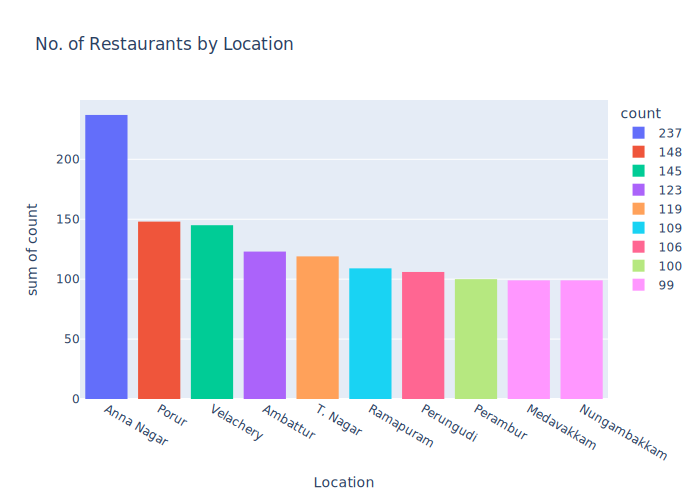

In [39]:
fig = px.histogram(location_df, x='Location', y= 'count', color='count',
 title= 'No. of Restaurants by Location',
 labels={'Location':'Location'})
fig.show()

In [40]:
# !pip install --upgrade kaleido

# Q2) What are the percentage of restaurants by Dining Rating in Chennai?

In [41]:
rating_type_df = zomato_df['Dining Rating'].value_counts().reset_index()
rating_type_df.rename(columns={'index':'Rating', 'RATING_TYPE':'COUNT OF RESTAURANTS'}, inplace=True)
rating_type_df

,Dining Rating,count
0,3.7,387
1,3.6,377
2,3.5,359
3,3.8,334
4,3.4,320
5,3.9,301
6,3.3,293
7,3.2,260
8,3.1,236
9,4.0,222


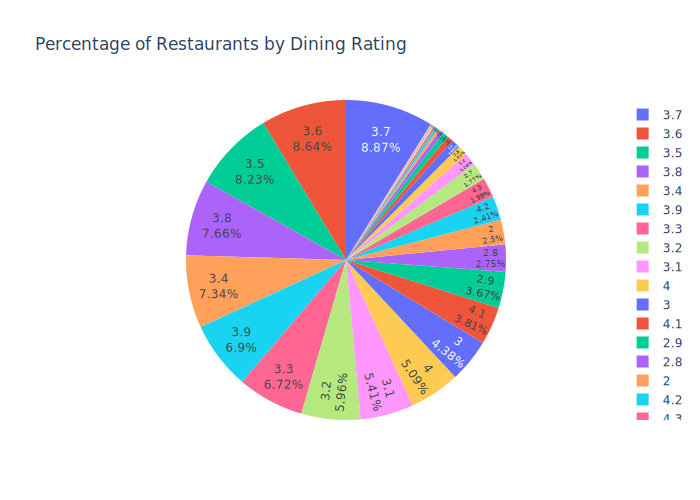

In [42]:
fig = px.pie(rating_type_df, names='Dining Rating', values='count', color='Dining Rating',
 title='Percentage of Restaurants by Dining Rating').update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# Q3) Which are the Top 10 highest rated North Indian food Restaurant in Chennai?

In [43]:
northindianfood_df = zomato_df[zomato_df['Cuisine'].str.contains('North Indian')]
northindianfood_df.sort_values(by='Dining Rating',ascending=False).head(10)

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
105,Bhangra,"Mayajaal Multiplex, Kanathur, Chennai","Mayajaal Multiplex, Kanathur",['North Indian'],"['Butter Chicken', ' Dal Makhani', ' Sweet Las...",800.0,4.9,2109,4.0,2226,"['Breakfast', 'Home Delivery', 'Mall Parking',..."
184,Gossip Fusion Bistro,"New 141, Old 191, Opposite HP Fuel Station, E...",Kanathur,"['Italian', ' Continental', ' Burger', ' Sandw...","['Tender Coconut Mousse', ' Iced Tea', ' Pasta...",1500.0,4.9,996,4.3,500,"['Breakfast', 'Home Delivery', 'Free Parking',..."
195,The Marina,"39, College Road, Nungambakkam, Chennai",Nungambakkam,"['Seafood', ' North Indian', ' Chinese']","['Sea Food', ' Jumbo Prawns', ' Biryani', ' Fi...",1600.0,4.8,1082,4.3,373,"['Home Delivery', 'Indoor Seating', 'Table res..."
173,Bombay Brasserie,"3, College Lane, Nungambakkam, Chennai",Nungambakkam,"['North Indian', ' Maharashtrian', ' Modern In...","['Biryani', ' Paratha', ' Naan', ' Kulfi', ' F...",1500.0,4.7,2546,4.2,1006,"['Home Delivery', 'Indoor Seating', 'Wifi', 'T..."
234,Hamsa,"New 40, Old 71A, B. Ramachandra Adithanar Roa...",Adyar,"['North Indian', ' Chettinad', ' Mughlai', ' D...","['Gulab Jamun', ' Cheese Kurkuri', ' Tomato Sh...",1800.0,4.6,825,4.4,241,"['Home Delivery', 'Wheelchair Accessible', 'Ve..."
116,AlMaza,"30, A Block, 6th Street, Near Titan Showroom,...",Anna Nagar,"['Arabian', ' Mughlai', ' North Indian', ' Bir...","['Faluda', ' Rara Gosht', ' Buttermilk', ' Naa...",1000.0,4.6,764,4.2,881,"['Home Delivery', 'Indoor Seating', 'Table boo..."
156,SpiceKlub,"H M Centre 29, Nungambakkam High Road, Nungam...",Nungambakkam,"['North Indian', ' Desserts', ' Beverages']","['Kulfi', ' Vada Pav', ' Panipuri', ' Pav Bhaj...",1700.0,4.6,1132,3.9,237,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
78,Shri Rajasthani Dhaba,"C 40, 3rd Floor, 2nd Avenue, Opposite KFC, An...",Anna Nagar,"['Rajasthani', ' North Indian']","['Rajasthani Thali', ' Buttermilk', ' Roti', '...",500.0,4.5,983,4.5,5537,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
242,Shyam's Bombay Halwa House,"6, Govindan Street, G N Chetty Road, T. Nagar...",T. Nagar,['North Indian'],"['Paneer Tikka', ' Paan Ice Cream', ' Tawa Pul...",600.0,4.5,798,3.9,63,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."
9037,Palmshore,"4/581 A, Velachery Main Road, Senthamizh Naga...",Medavakkam,"['North Indian', ' Chinese', ' Arabian', ' BBQ...","['Mutton Mandi', ' Biryani', ' Brownie', ' Bbq...",1000.0,4.5,1942,3.8,4379,"['Home Delivery', 'Valet Parking Available', '..."


# Q4) Which restaurants offer the most features (WiFi, Parking, etc.)?

In [44]:
features_df=zomato_df['Features'].value_counts().reset_index().head(10)
features_df.rename(columns={'index':'Features', 'Features_TYPE':'COUNT OF RESTAURANTS'}, inplace=True)
features_df

,Features,count
0,"['Home Delivery', 'Indoor Seating']",1375
1,"['Breakfast', 'Home Delivery', 'Indoor Seating']",257
2,"['Home Delivery', 'Free Parking', 'Indoor Seat...",211
3,"['Home Delivery', 'Indoor Seating', 'Desserts ...",189
4,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",144
5,"['Home Delivery', 'Vegetarian Only', 'Indoor S...",106
6,"['Home Delivery', 'Vegetarian Only', 'Indoor S...",101
7,"['Home Delivery', 'Outdoor Seating']",88
8,"['Home Delivery', 'Indoor Seating', 'Free Park...",69
9,"['Breakfast', 'Home Delivery', 'Free Parking',...",58


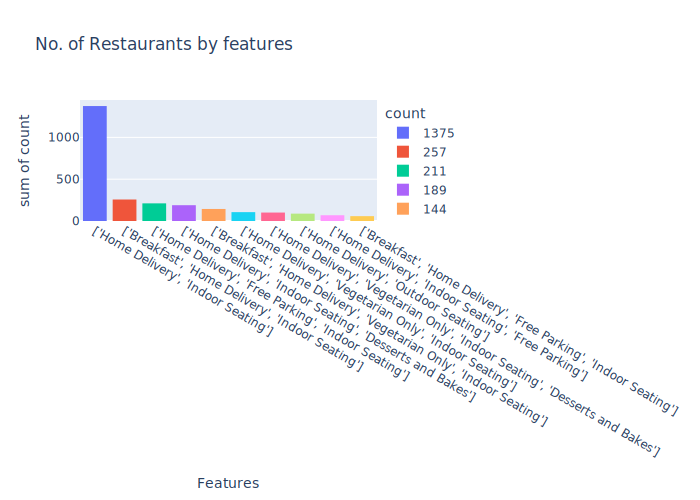

In [45]:
fig = px.histogram(features_df, x='Features', y= 'count', color='count',
 title= 'No. of Restaurants by features',
 labels={'Count':'count'})
fig.show()

# Q5) Which places have the highest rated restaurant for each Cuisine Type in Chennai?

In [46]:
# Assuming restaurants having rating above 4.5
highest_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5]
highest_rated_df

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
24,Eating Circles,"6, CP Ramaswamy Road, Alwarpet, Chennai",Alwarpet,['South Indian'],"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",250.0,4.7,782,4.2,2744,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
37,Shree Mithai,"18, Dr TV Road, Chetpet, Chennai",Chetpet,"['Mithai', ' Street Food', ' Fast Food']","['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",300.0,4.6,1085,4.4,18600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
50,Andhikkadai,"20, Dhandeeswaram Main Road, Velachery, Chennai",Velachery,['South Indian'],"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po...",200.0,4.6,908,4.2,17300,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
57,Brownie Heaven,"193, Peters Road, Opposite New College, Royap...",Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",350.0,4.9,842,4.3,2270,"['Home Delivery', 'Indoor Seating', 'Desserts ..."
59,Mezze,"Abhinav Center, Old Number 19, New Number 4, ...",Alwarpet,['Middle Eastern'],"['Baklava', ' Mezze', ' Shawarma', ' Pita Brea...",700.0,4.7,1152,4.2,2249,"['Home Delivery', 'Indoor Seating']"
62,Amadora Gourmet Ice Cream & Sorbet,"23, Wallace Garden, 3rd Street, Nungambakkam,...",Nungambakkam,"['Desserts', ' Ice Cream']","['Sandwich', ' Gelato', ' Chocolate Icecreams'...",500.0,4.8,1516,4.5,361,"['Home Delivery', 'Outdoor Seating', 'Desserts..."
67,Pumpkin Tales,"37/20, Bheemanna Garden Street, Alwarpet, Che...",Alwarpet,"['Singaporean', ' American', ' European', ' Co...","['Pumpkin Soup', ' Bibimbap', ' Noodle', ' Che...",1800.0,4.5,768,4.0,245,"['Breakfast', 'Home Delivery', 'Indoor Seating..."
68,Sandy's Chocolate Laboratory,"16, Wallace Garden, 2nd Street, Nungambakkam,...",Nungambakkam,"['Cafe', ' Continental', ' Italian', ' Desserts']","['Tiny Chocolate Cake', ' Hot Chocolate', ' Sa...",1400.0,4.5,2252,4.3,1973,"['Breakfast', 'Home Delivery', 'Free Parking',..."
70,Little Italy,"E-50, 17th Cross Street, Lane Before Spencers...",Besant Nagar,"['Italian', ' Mexican', ' Salad']","['Pasta', ' Pizza', ' Nachos', ' Tiramisu', ' ...",1500.0,4.7,1349,4.2,1435,"['Home Delivery', 'Vegetarian Only', 'Valet Pa..."
75,Fusilli Reasons,"2/64, Ormes Main Road, Kilpauk, Chennai",Kilpauk,['Fast Food'],"['Nachos', ' Iced Tea', ' Garlic Bread', ' Bro...",400.0,4.7,3042,4.4,3954,"['Home Delivery', 'Vegetarian Only', 'Indoor S..."


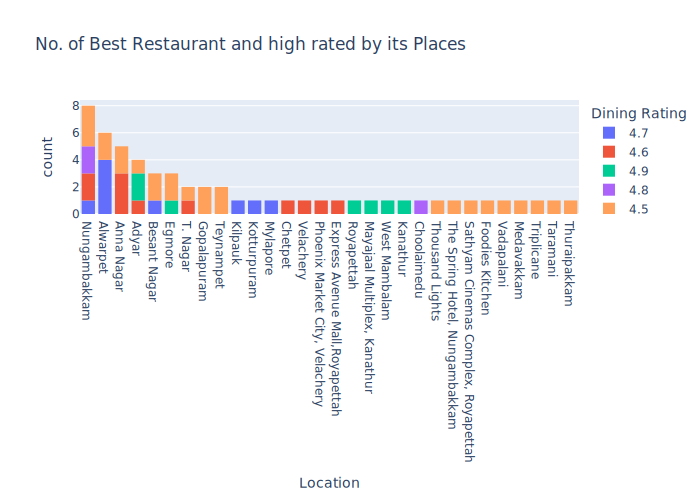

In [47]:
fig = px.histogram(highest_rated_df, x='Location', color='Dining Rating',
 title= 'No. of Best Restaurant and high rated by its Places').update_xaxes(categoryorder="total descending")
fig.show()

# Q6) What is the Avg Price Distibution of highest rated restaurant in Chennai?

In [48]:
highest_rated_price_df = highest_rated_df.groupby(by=['Location', 'Cuisine'])['Price for 2'].mean().reset_index()
highest_rated_price_df.head()

,Location,Cuisine,Price for 2
0,Adyar,"['Chinese', ' Thai']",800.0
1,Adyar,['Ice Cream'],200.0
2,Adyar,"['North Indian', ' Chettinad', ' Mughlai', ' D...",1800.0
3,Adyar,['South Indian'],500.0
4,Alwarpet,"['Desserts', ' Ice Cream']",350.0


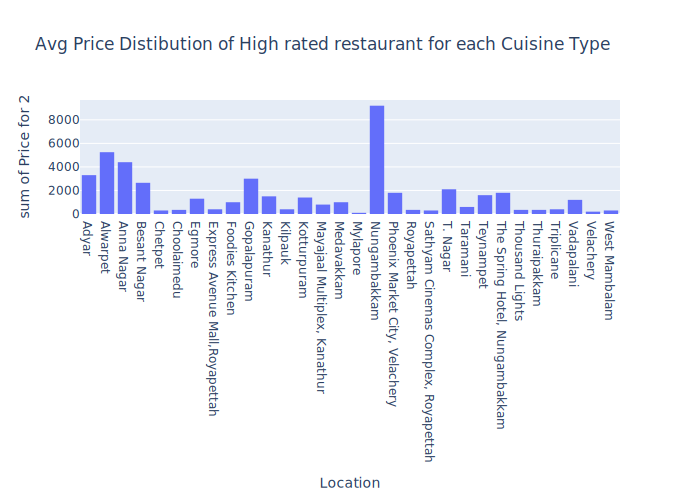

In [49]:
fig = px.histogram(highest_rated_price_df, x="Location", y="Price for 2", 
 title=' Avg Price Distibution of High rated restaurant for each Cuisine Type')
fig.show()

# Q7) Which areas have a large number of Chinese Restaurant Market?

In [50]:
chinese_df = zomato_df[zomato_df['Cuisine'].str.contains('Chinese')]
chinese_df

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
5,Dine N Fun,"Opposite Forest Office, Tambaram Main Road, S...",Medavakkam,"['South Indian', ' North Indian', ' Chinese']","['Chicken Grill', ' Shawarma', ' Naan', ' Chic...",450.0,4.1,567,3.8,24700,"['Home Delivery', 'Indoor Seating']"
8,Savoury Sea Shell,"3, E Block, 3rd Avenue, Anna Nagar East, Chennai",Anna Nagar,"['Arabian', ' Chinese', ' North Indian', ' Leb...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",1400.0,4.2,2564,4.1,21700,"['Home Delivery', 'Indoor Seating', 'Card Upon..."
9,Sangeetha Veg Restaurant,"102/82, GN Chetty Road, T. Nagar, Chennai",T. Nagar,"['South Indian', ' North Indian', ' Chinese', ...","['Filtered Coffee', ' Chaat', ' Faluda', ' Mas...",800.0,4.4,1578,4.2,39600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
...,...,...,...,...,...,...,...,...,...,...,...
11382,Texas Treat,"1/191, Velachery Main Road, Santhoshapuram, S...",Selaiyur,"['Bakery', ' North Indian', ' Chinese', ' Ital...",NA,850.0,3.8,9,3.8,43,"['Home Delivery', 'Vegetarian Only', 'Free Par..."
11544,Anandhi Idly Kadai,"5, Mpn Complex, Pillaiyar Koil Street, Medava...",Medavakkam,"['South Indian', ' Chinese']",NA,200.0,3.4,24,4.1,778,"['Home Delivery', 'Indoor Seating']"
11545,Anandhi Idly Kadai,"202, Velachery, Main Road, Camp Road, Junctio...",Selaiyur,"['South Indian', ' Chinese']",NA,200.0,3.1,17,4.1,367,"['Breakfast', 'Home Delivery', 'Indoor Seating']"
11736,Adyar Vaishnavas Thattu Idly Kadai,"3/103, Mugalivakkam Main Road, Madanandapuram...",Porur,"['South Indian', ' Sandwich', ' Chinese', ' St...",NA,200.0,3.2,6,3.9,48,"['Home Delivery', 'Indoor Seating']"


In [51]:
chinese_rest_df = chinese_df.groupby(by='Location').agg({'Name of Restaurant' : 'count', 'Price for 2' : 'mean'}).rename(columns= {'Name of Restaurant':'Count of Restaurants',
                                                                                                                                     'Price for 2': 'AVERAGE PRICE'})
chinese_rest_df = chinese_rest_df.sort_values('Count of Restaurants', ascending=False).head(25)
chinese_rest_df.head()

,Count of Restaurants,AVERAGE PRICE
Location,,
Anna Nagar,95,585.789474
Porur,58,490.517241
Ambattur,52,415.384615
T. Nagar,47,501.063830
Velachery,46,576.086957


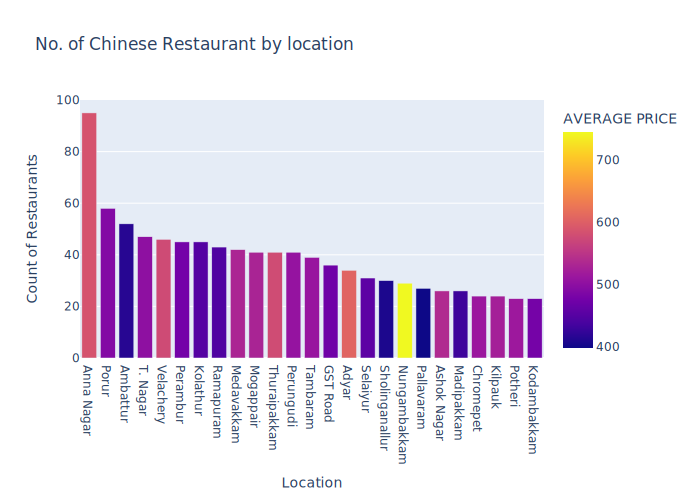

In [52]:
chinese_rest_df = chinese_rest_df.reset_index()
fig = px.bar(chinese_rest_df, x ='Location', y ='Count of Restaurants', color= 'AVERAGE PRICE', title= 'No. of Chinese Restaurant by location')
fig.show()

# Q8) Is there a relation between Price and Rating by each Cuisine?

In [53]:
price_rating_df = zomato_df.groupby(['Cuisine', 'Dining Rating'])['Price for 2'].mean().reset_index()
price_rating_df

,Cuisine,Dining Rating,Price for 2
0,"['American', ' Continental', ' European', ' It...",3.9,700.0
1,"['American', ' Continental', ' Italian', ' Nor...",4.1,800.0
2,"['American', ' Continental']",4.1,1600.0
3,"['American', ' Fast Food']",2.7,300.0
4,"['American', ' Fast Food']",3.9,500.0
...,...,...,...
2881,"['Tibetan', ' Momos']",3.1,400.0
2882,"['Tibetan', ' Momos']",3.4,400.0
2883,"['Tibetan', ' Momos']",3.5,400.0
2884,"['Tibetan', ' Momos']",3.6,400.0


In [54]:
fig = px.line(price_rating_df, y="Dining Rating", x="Price for 2")

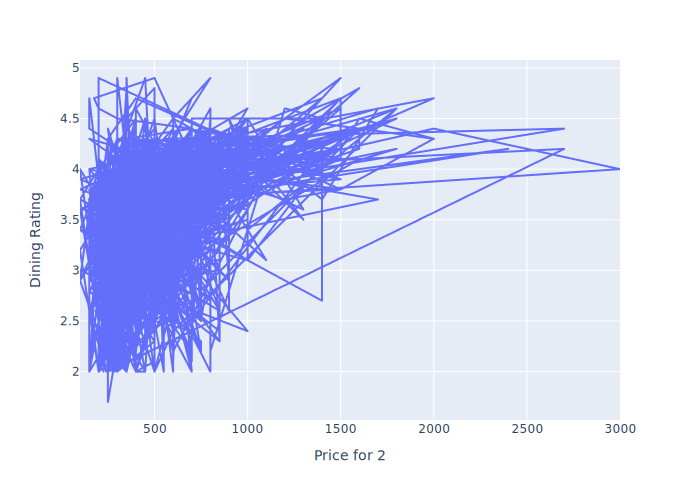

In [55]:
fig.show()

# Q9) Is there a relation between Region and Price?

In [56]:
region_price_df = zomato_df.groupby(['Location'])['Price for 2'].mean().reset_index()
region_price_df

,Location,Price for 2
0,Abhiramapuram,200.000000
1,Adambakkam,327.631579
2,Adyar,528.865979
3,Akkarai,575.000000
4,Alandur,442.857143
...,...,...
154,Vepery,350.000000
155,Vettuvankeni,475.000000
156,Virugambakkam,425.000000
157,Washermenpet,380.555556


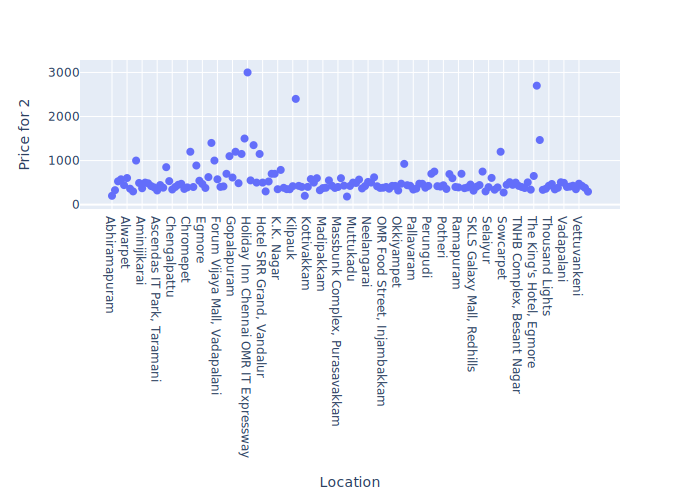

In [57]:
fig = px.scatter(region_price_df, x="Location", y="Price for 2").update_traces(marker_size=8)
fig.show()

# Q10) Find the list of Affordable Restaurants?

# The criteria for Affordable Restaurants would be:

# 1) Low Price 2) High Rated
# First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.
# Let me explain:-The most expensive restaurant has an average meal cost= 3000. We'll try to stay economical and only pick the restaurants that are 1/4th of 3000.

In [58]:
max_price = zomato_df['Price for 2'].max()
one_fourth_price = max_price/4
print(one_fourth_price)

750.0


In [59]:
# Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restaurant	
aff_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location']]
aff_rest_df = aff_rest_df[aff_rest_df['Price for 2'] <= 750]
aff_rest_df.sort_values(by='Price for 2', inplace=True)
aff_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location
2820,Devasahayam Pillai Enterprises,100.0,['South Indian'],Adyar
11051,Kulfi Treat,100.0,['Ice Cream'],Porur
5015,Zum Zum Super Cooldrinks & Snacks,100.0,['Beverages'],Red Hills
3542,Vijayarams Coffee,100.0,"['Cafe', ' Bakery', ' Juices', ' North Indian'...",T. Nagar
2921,Cheta Butter Milk,100.0,['Beverages'],Thousand Lights
...,...,...,...,...
533,Courtallam Border Parotta,750.0,"['North Indian', ' South Indian', ' Chettinad']",Velachery
10071,Long Live Pizza,750.0,"['Pizza', ' Fast Food']","OMR Food Street, Guduvancheri"
10074,Long Live Pizza,750.0,"['Pizza', ' Fast Food']",Injambakkam
1615,Betel Leaf,750.0,"['Chettinad', ' Chinese', ' Seafood', ' North ...",Kodambakkam


In [60]:
# Finding the highest rated list of restaurants
highrate_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location','Dining Rating']]
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating'] >= 4.5]
highrate_rest_df.sort_values(by='Price for 2', inplace=True)
highrate_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating
108,Rayar's Mess,100.0,['South Indian'],Mylapore,4.7
178,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet,4.7
50,Andhikkadai,200.0,['South Indian'],Velachery,4.6
320,Bombay Kulfi,200.0,['Ice Cream'],Adyar,4.9
9541,Bombay Kulfi,200.0,['Ice Cream'],Anna Nagar,4.6
24,Eating Circles,250.0,['South Indian'],Alwarpet,4.7
155,The Sandwich Shop,300.0,"['Sandwich', ' Fast Food', ' Beverages']",West Mambalam,4.9
37,Shree Mithai,300.0,"['Mithai', ' Street Food', ' Fast Food']",Chetpet,4.6
270,ID,300.0,['South Indian'],"Sathyam Cinemas Complex, Royapettah",4.5
163,Momo Sa-Khang by Kailash Kitchen,350.0,"['Momos', ' Chinese']",Choolaimedu,4.8


In [61]:
highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['Name of Restaurant', 'Location'])
highrate_aff_df = highrate_aff_df[['Name of Restaurant', 'Price for 2_x', 'Cuisine_x', 'Location']]
highrate_aff_df.rename(columns={'Name of Restaurant':'NAME', 'Price for 2_x':'PRICE', 'Cuisine_x':'Cuisine',
 'Location':'Location'},inplace=True)

In [62]:
# Affordable Restaurants with low price and high rating 
highrate_aff_df

,NAME,PRICE,Cuisine,Location
0,Rayar's Mess,100.0,['South Indian'],Mylapore
1,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
2,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
3,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
4,Bombay Kulfi,200.0,['Ice Cream'],Anna Nagar
5,Bombay Kulfi,200.0,['Ice Cream'],Adyar
6,Andhikkadai,200.0,['South Indian'],Velachery
7,Eating Circles,250.0,['South Indian'],Alwarpet
8,Shree Mithai,300.0,"['Mithai', ' Street Food', ' Fast Food']",Chetpet
9,ID,300.0,['South Indian'],"Sathyam Cinemas Complex, Royapettah"


# Q11) Find the list of most Reliable Restaurants?

# The criteria for most Reliable Restaurants would be:-

# 1) Low Price 2) High Rated 3) Large No. of Delivery

# First step will be to find the restaurants with delivery rating greater than Mean of delivery rating

In [63]:
mean_votes = zomato_df['Delivery Rating'].mean()
print(mean_votes)

3.8435450584728277


In [64]:
# Finding list of restaurants that have Votes greater than and equal to Mean of Vote
mean_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location','Delivery Rating']]
mean_rest_df = mean_rest_df[mean_rest_df['Delivery Rating'] > 3.8]
mean_rest_df.sort_values(by='Delivery Rating', inplace=True)
mean_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Delivery Rating
11090,The Cake World,500.0,['Bakery'],Valasaravakkam,3.9
11091,The Cake World,500.0,['Bakery'],Anna Nagar,3.9
11093,The Cake World,500.0,['Bakery'],Teynampet,3.9
11095,The Cake World,500.0,['Bakery'],Egatoor,3.9
11096,The Cake World,500.0,['Bakery'],K.K. Nagar,3.9
...,...,...,...,...,...
473,Dynasty,1200.0,"['Chinese', ' Seafood']","Harrisons Hotel, Nungambakkam",4.6
8999,Domino's Pizza,400.0,"['Pizza', ' Fast Food']",Porur,4.6
9977,ibaco,200.0,['Ice Cream'],Mylapore,4.7
4371,Mumbai Kulfi,150.0,['Desserts'],Pallavaram,4.7


# These are the most reliable, highest rated and affordable restaurants:-

# We obtain this dataframe by simply taking the intersection of highrate_aff_df & mean_rest_df
# This dataframe obtained below shows the restaurants whose:

# Cost is below 1250
# Rating is above 4.5
# Delivery Rating are above 3.8

In [65]:
print(mean_rest_df.columns)


Index(['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location',
       'Delivery Rating'],
      dtype='object')


In [66]:
print(highrate_aff_df.columns)

Index(['NAME', 'PRICE', 'Cuisine', 'Location'], dtype='object')


In [67]:
highrate_aff_df.rename(columns={'NAME':'Name of Restaurant','PRICE':'Price for 2'}, inplace=True)

In [68]:
print(mean_rest_df.columns)
print(highrate_aff_df.columns)

Index(['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location',
       'Delivery Rating'],
      dtype='object')
Index(['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location'], dtype='object')


In [69]:
reliable_rest_df = pd.merge(mean_rest_df, highrate_aff_df, how='inner', on=['Name of Restaurant', 'Location'])
reliable_rest_df = reliable_rest_df[['Name of Restaurant', 'Price for 2_x', 'Cuisine_x', 'Location']]
reliable_rest_df.rename(columns={'Name of Restaurant':'NAME', 'Price for 2_x':'PRICE', 'Cuisine_x':'Cuisine','Location':'Location'},inplace=True)

In [70]:
reliable_rest_df

,NAME,PRICE,Cuisine,Location
0,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
1,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
2,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
3,Shyam's Bombay Halwa House,600.0,['North Indian'],T. Nagar
4,Blind Ch3mistry,700.0,"['Cafe', ' Continental', ' Italian', ' Dessert...",Besant Nagar
5,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
6,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
7,Royal Sandwich Shop,150.0,"['Fast Food', ' Desserts', ' Beverages']",Alwarpet
8,Cream Stone,350.0,"['Desserts', ' Ice Cream']",Alwarpet
9,Blind Ch3mistry,700.0,"['Cafe', ' Continental', ' Italian', ' Dessert...",Nungambakkam
